# ML.ENERGY Phase 4.0 — 565-run GPU steady-state power candidate

## tl;dr

- The locked candidate is **RandomForest + P2-HardwareStatic + L1**.
- Development model-group OOF: **272.4 W MAE**, **474.3 W RMSE**, **R² 0.941** on 449 rows / 21 models.
- One-shot confirmatory holdout: **295.3 W MAE**, **424.6 W RMSE**, **R² 0.921** on 116 rows / 6 models.
- All 565 stable runs, including 117 Llama runs, enter P0/P1/P2. The remaining failure modes are lineage extrapolation and high-power / 8-GPU underprediction.

This is a read-only evidence companion. It loads persisted artifacts and performs no fitting or model selection.


## Context & Methods

Scope is ML.ENERGY V3 **GPU-side text-LLM inference** under high-load / near-saturation steady-state operation. The only formal target is aggregate GPU average power in watts. Formal inputs are execution-time-known. Model identity, lineage, task outcome, actual tokens, throughput, latency, duration, utilization, and other post-run telemetry are excluded from X.

Six model IDs were selected by stable hash within parent lineage before Phase 4 training and held out from every development decision. The notebook distinguishes development model-group OOF, the one-shot confirmatory evaluation, and full-cohort diagnostic OOF.


In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
assert (ROOT / "step6").exists(), "Execute from the repository root"
STEP6 = ROOT / "step6"
REPORTS = STEP6 / "reports"
FIGURES = REPORTS / "figures"

table = pd.read_parquet(STEP6 / "analysis/phase4_power_modeling_table.parquet")
main = pd.read_csv(REPORTS / "main_model_comparison.csv")
ablation = pd.read_csv(REPORTS / "hardware_ablation.csv")
losses = pd.read_csv(REPORTS / "loss_strategy_comparison.csv")
confirmatory = pd.read_csv(REPORTS / "confirmatory_metrics.csv")
lineage = pd.read_csv(REPORTS / "generalization_by_lineage.csv")
within_task = pd.read_csv(REPORTS / "within_task_lineage_holdout.csv")
architecture = pd.read_csv(REPORTS / "architecture_holdout.csv")
slices = pd.read_csv(REPORTS / "error_slices.csv")
static = pd.read_csv(REPORTS / "static_subset_comparison.csv")
lock = json.loads((STEP6 / "config/locked_candidate_phase4.json").read_text(encoding="utf-8"))
holdout = json.loads((STEP6 / "config/confirmatory_model_holdout.json").read_text(encoding="utf-8"))

pd.Series({
    "stable runs": len(table),
    "model IDs": table["diag_model_id"].nunique(),
    "Llama runs": table["diag_parent_lineage"].eq("Llama").sum(),
    "development runs": table["eligible_phase4_development"].sum(),
    "confirmatory runs": table["diag_is_confirmatory_model"].sum(),
}).to_frame("count")


,count
stable runs,565
model IDs,27
Llama runs,117
development runs,449
confirmatory runs,116


## Data

P0-Core, P1-AggregatePower, and P2-HardwareStatic all cover the full 565-run cohort. Lineage and subfamily fields are diagnostic only; architecture class is the structural category permitted in X. Hardware fields reuse the frozen Phase 3 H100/B200 reference proxies and do not establish cross-generation physical scaling.


,group,runs,models,level
0,DeepSeek,22,2,parent_lineage
1,GPT-OSS,65,2,parent_lineage
2,Gemma,29,2,parent_lineage
3,Llama,117,7,parent_lineage
4,Nemotron,56,2,parent_lineage
5,Qwen,276,12,parent_lineage
6,dense_transformer,203,10,architecture_class
7,hybrid_mamba_transformer,56,2,architecture_class
8,mixture_of_experts,306,15,architecture_class


,runs
x_hardware_gpu_model,
B200,291
H100,274


,runs
x_hardware_num_gpus,
1,250
2,104
4,83
8,128


,runs
x_protocol_task,
gpqa,187
lm-arena-chat,328
sourcegraph-fim,50


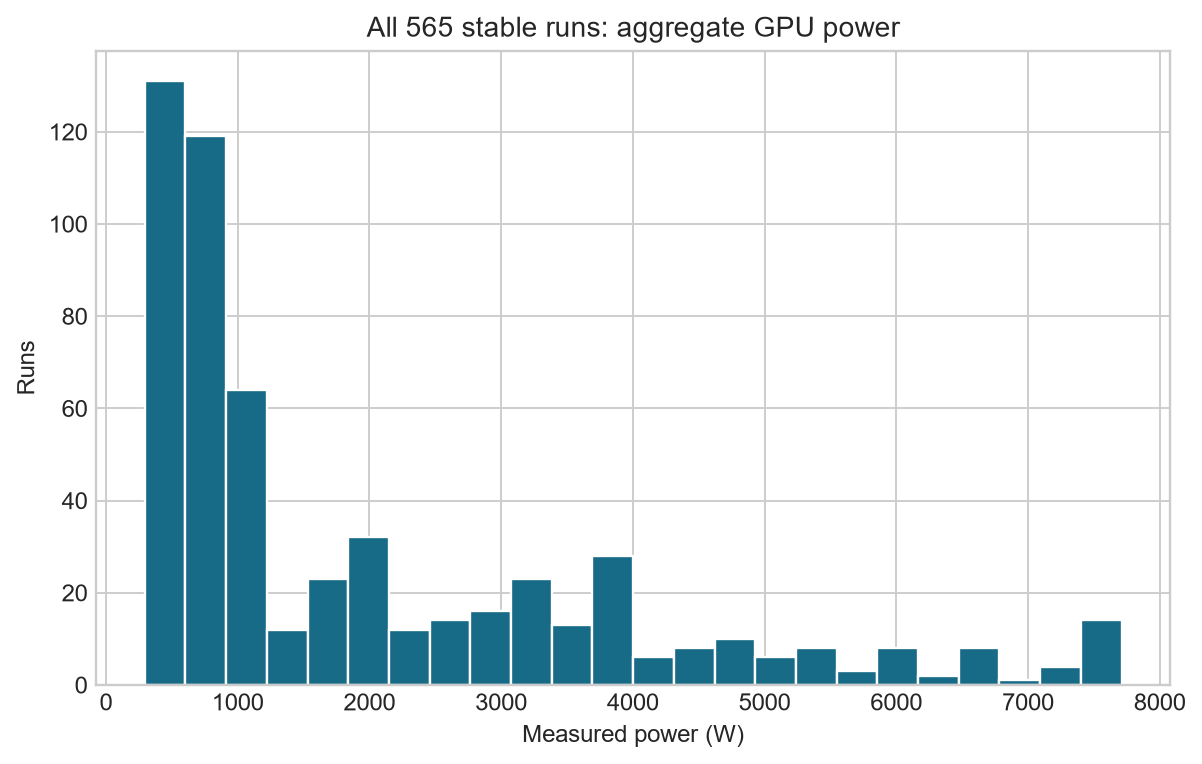

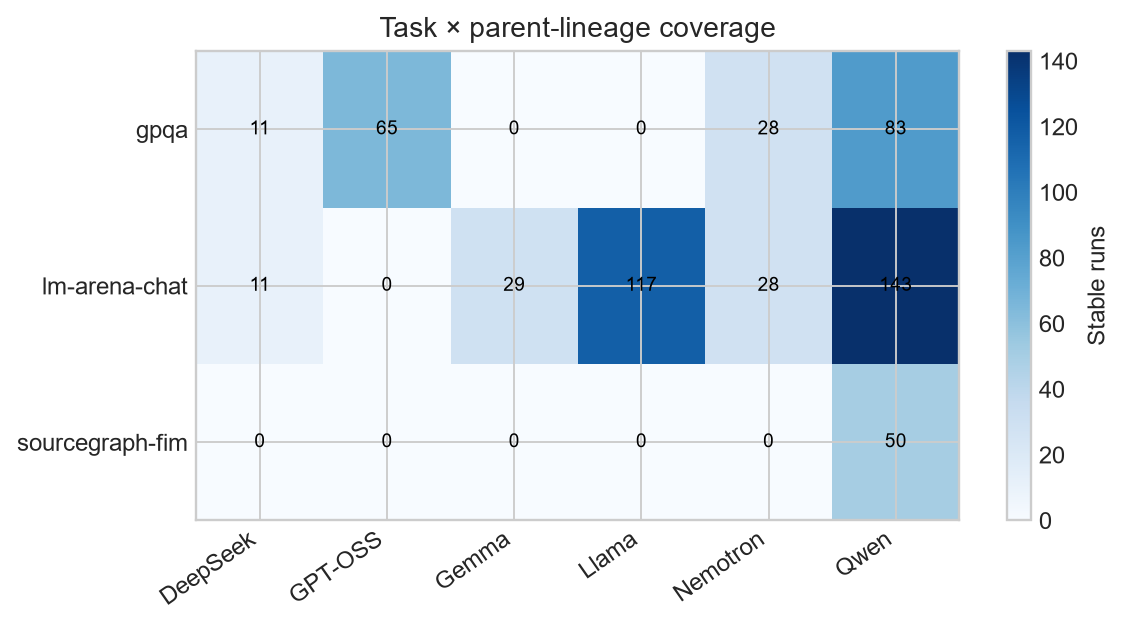

In [2]:
coverage = pd.concat([
    table.groupby("diag_parent_lineage").agg(runs=("run_key", "size"), models=("diag_model_id", "nunique")).assign(level="parent_lineage"),
    table.groupby("diag_architecture_class").agg(runs=("run_key", "size"), models=("diag_model_id", "nunique")).assign(level="architecture_class"),
])
display(coverage.reset_index().rename(columns={"index": "group"}))
display(table.groupby("x_hardware_gpu_model").size().rename("runs").to_frame())
display(table.groupby("x_hardware_num_gpus").size().rename("runs").to_frame())
display(table.groupby("x_protocol_task").size().rename("runs").to_frame())
display(Image(filename=str(FIGURES / "target_distribution.png"), width=950))
display(Image(filename=str(FIGURES / "task_parent_lineage_heatmap.png"), width=950))


## Results — development selection and hardware ablation

The main matrix uses the same 449 development rows and frozen model-group folds for six algorithms and four bundles. Candidate selection uses MAE first, with RMSE and high-power bias guardrails. P2-NoLabel remains a sensitivity analysis.


,algorithm,feature_bundle,mae,rmse,r2,mdape,smape,signed_bias
0,RandomForest,P2-HardwareStatic,272.402,474.325,0.941,10.055,13.614,37.582
1,XGBoost,P0-Core,277.294,508.086,0.932,11.250,15.118,-31.762
2,CatBoost,P2-HardwareStatic,280.972,572.600,0.914,9.132,14.277,-66.846
4,HistGradientBoosting,P1-AggregatePower,284.132,513.046,0.931,10.164,13.860,93.375
5,HistGradientBoosting,P0-Core,288.437,557.053,0.918,10.033,14.685,0.919
6,HistGradientBoosting,P2-HardwareStatic,294.930,540.061,0.923,10.162,13.937,93.418
8,CatBoost,P1-AggregatePower,296.238,588.247,0.909,10.043,14.705,-26.904
9,RandomForest,P0-Core,297.960,628.240,0.896,9.177,14.701,-3.283
12,RandomForest,P1-AggregatePower,309.610,571.101,0.914,11.124,14.436,61.041
13,XGBoost,P1-AggregatePower,311.581,553.186,0.920,11.971,15.254,46.856


,algorithm,comparison,row_weighted_delta_mae,row_weighted_ci_low,row_weighted_ci_high,equal_model_delta_mae
0,CatBoost,P0_to_P1,-26.017,-51.493,-4.823,-32.493
1,CatBoost,P1_to_P2,-15.266,-62.986,20.798,-22.065
2,CatBoost,P2_to_P2_NoLabel,18.948,-16.432,63.743,17.128
9,RandomForest,P0_to_P1,11.651,-133.853,161.012,-30.776
10,RandomForest,P1_to_P2,-37.209,-94.774,-1.551,-35.068
11,RandomForest,P2_to_P2_NoLabel,11.511,1.588,26.821,15.386
12,Ridge,P0_to_P1,-44.066,-89.738,-7.564,-62.480
13,Ridge,P1_to_P2,-13.852,-34.534,4.694,-15.590
14,Ridge,P2_to_P2_NoLabel,0.006,-0.269,0.368,0.026
15,XGBoost,P0_to_P1,34.287,-27.357,114.577,31.830


,feature_bundle,n_rows,n_models,mae,rmse,r2,mdape,smape,signed_bias
0,S0-B1-Static,448,20,189.708,300.042,0.973,10.106,13.728,-23.593
1,S1-B1-Static-AggregatePower,448,20,176.881,285.217,0.976,9.337,13.341,-24.431
2,S2-B1-Static-HardwareStatic,448,20,183.031,295.073,0.974,9.838,13.510,-28.216


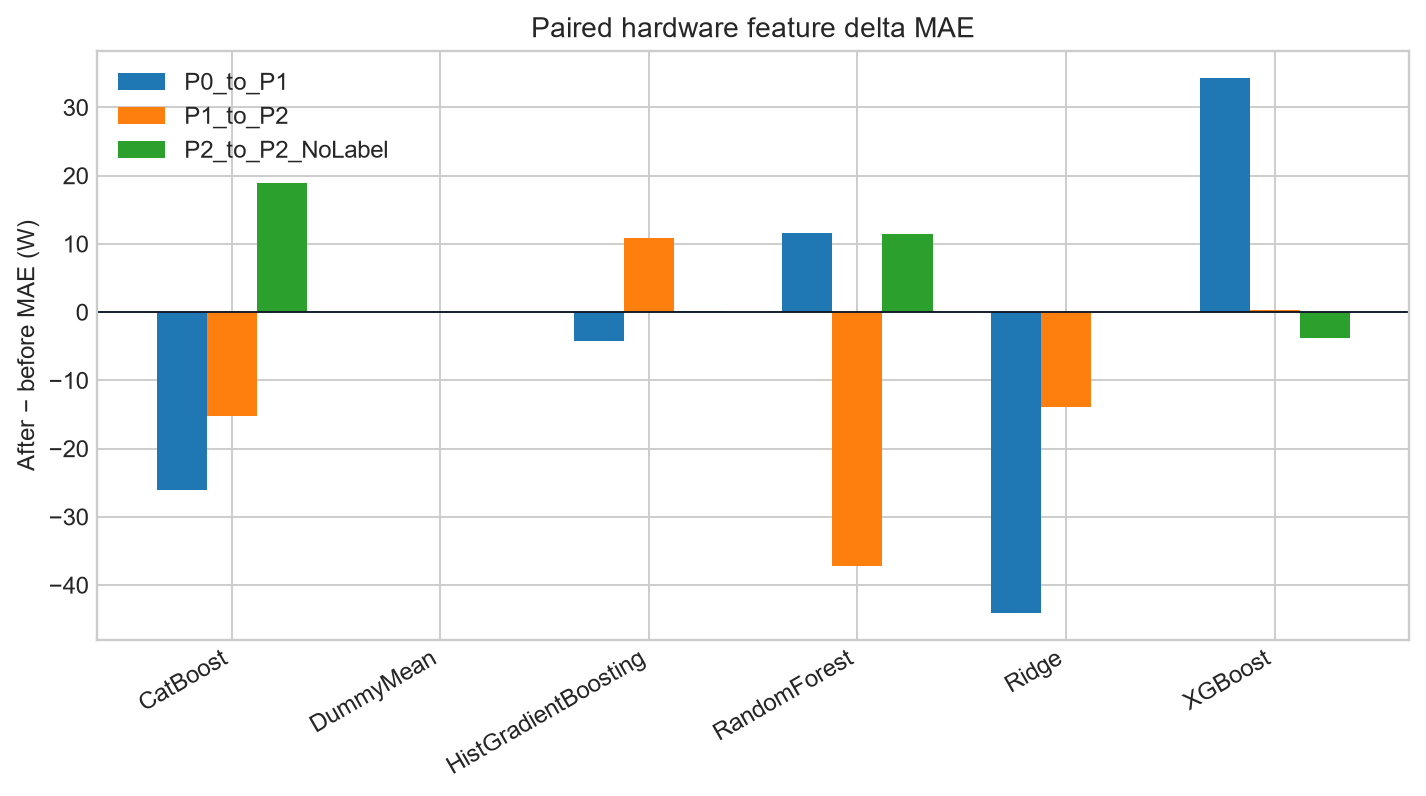

In [3]:
display(
    main.loc[main["feature_bundle"].isin(["P0-Core", "P1-AggregatePower", "P2-HardwareStatic"])]
    .sort_values("mae")
    [["algorithm", "feature_bundle", "mae", "rmse", "r2", "mdape", "smape", "signed_bias"]]
    .round(3)
)
display(
    ablation.loc[ablation["algorithm"].isin(["RandomForest", "CatBoost", "Ridge", "XGBoost"])]
    [["algorithm", "comparison", "row_weighted_delta_mae", "row_weighted_ci_low", "row_weighted_ci_high", "equal_model_delta_mae"]]
    .round(3)
)
display(static.round(3))
display(Image(filename=str(FIGURES / "hardware_paired_mae_delta.png"), width=950))


## Results — loss strategy and confirmatory holdout

L2, pseudo-Huber, and mild high-power weighting do not improve the overall/high-power tradeoff. The final L1 candidate was locked before confirmatory predictions were generated. Confirmatory rows are never fed back into tuning.


,strategy_id,mae,rmse,r2,top25_mae,top25_signed_bias,top10_mae,top10_signed_bias,lower75_mae
0,RandomForest_P2-HardwareStatic_L1,272.402,474.325,0.941,682.401,-9.938,1009.372,-392.471,134.515
1,XGBoost_P0-Core_L1,277.294,508.086,0.932,674.793,-168.976,1033.327,-866.013,143.611
2,RandomForest_P2-HardwareStatic_L2,285.193,483.572,0.939,688.981,-92.712,1058.420,-492.177,149.395
3,XGBoost_P0-Core_L1_weighted,304.887,531.222,0.926,715.100,-115.100,1066.075,-867.924,166.929
4,RandomForest_P2-HardwareStatic_L1_weighted,313.501,557.224,0.918,809.899,97.452,1091.394,-347.823,146.557
5,XGBoost_P0-Core_L2,331.944,619.121,0.899,829.955,-135.076,1270.108,-806.983,164.458
6,XGBoost_P0-Core_PseudoHuber,343.886,591.168,0.908,841.887,2.129,1193.541,-699.734,176.404


,slice_type,slice_value,n_rows,n_models,mae,rmse,r2,mdape,smape,signed_bias
0,overall,all,116,6,295.264,424.612,0.921,16.462,19.580,187.731
1,diag_parent_lineage,DeepSeek,5,1,534.720,663.351,0.551,6.876,9.248,-478.495
2,diag_parent_lineage,GPT-OSS,39,1,388.936,406.327,-0.769,38.934,33.307,388.936
3,diag_parent_lineage,Gemma,16,1,81.281,100.340,0.744,7.301,9.726,-61.547
4,diag_parent_lineage,Llama,9,1,973.301,1047.686,-2.080,27.070,31.567,973.301
5,diag_parent_lineage,Nemotron,29,1,72.168,89.084,0.515,14.074,13.141,6.335
6,diag_parent_lineage,Qwen,18,1,236.413,333.757,0.879,3.472,5.848,57.891
7,x_hardware_gpu_model,B200,60,5,293.398,373.953,0.958,17.150,20.311,100.871
8,x_hardware_gpu_model,H100,56,5,297.264,472.905,0.739,15.581,18.797,280.794
9,x_hardware_num_gpus,1,52,3,174.932,244.102,-1.337,16.462,22.131,105.508


,value
locked strategy,RandomForest_P2-HardwareStatic_L1
held-out models,6


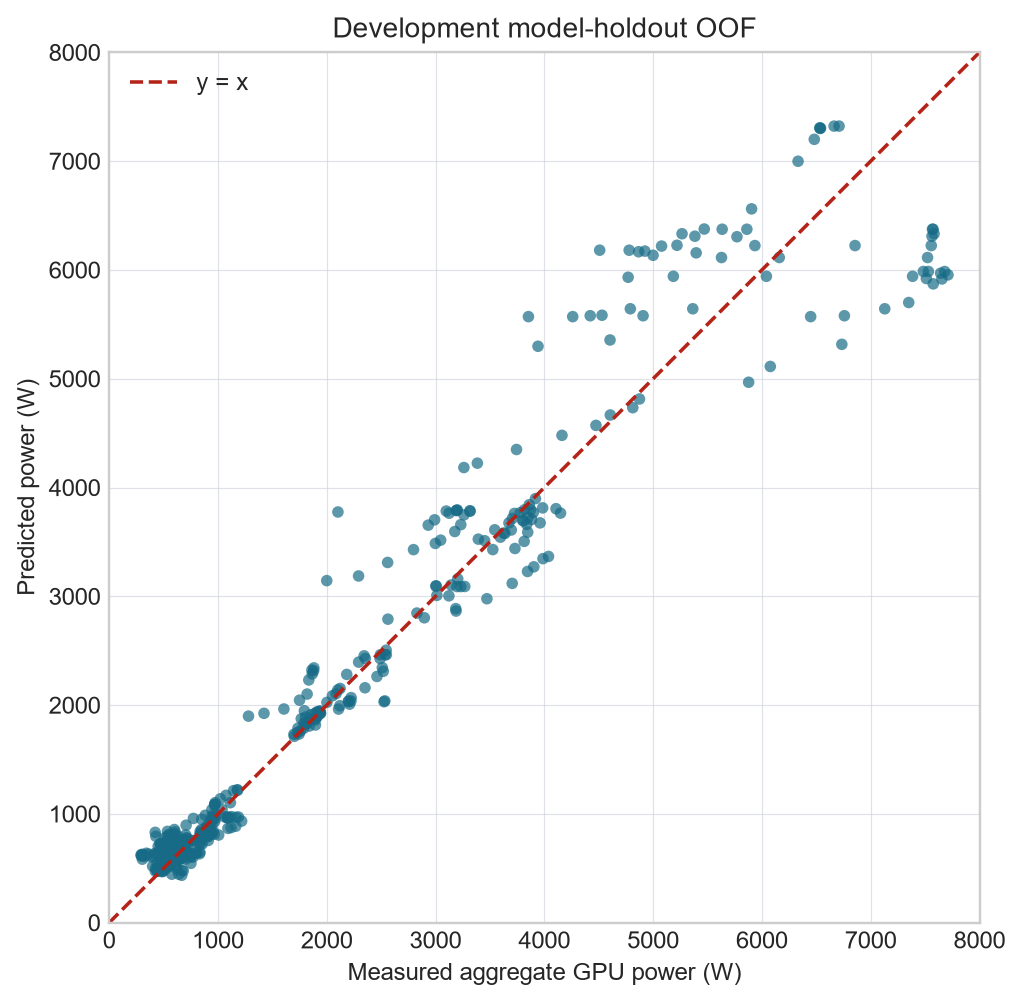

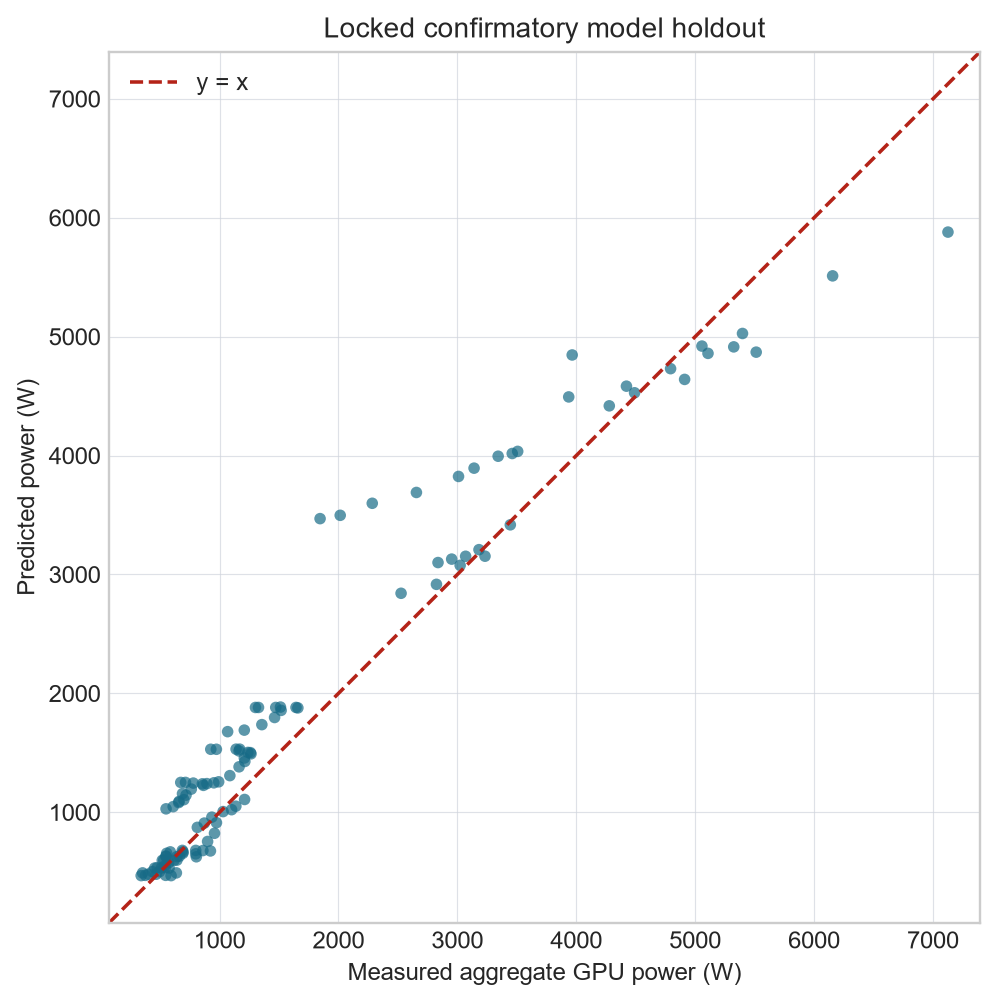

In [4]:
display(
    losses[["strategy_id", "mae", "rmse", "r2", "top25_mae", "top25_signed_bias", "top10_mae", "top10_signed_bias", "lower75_mae"]]
    .sort_values("mae").round(3)
)
display(confirmatory.round(3))
display(pd.Series({"locked strategy": lock["selected"]["strategy_id"], "held-out models": len(holdout["held_out_model_ids"])}).to_frame("value"))
for name in ("development_actual_vs_predicted.png", "confirmatory_actual_vs_predicted.png"):
    display(Image(filename=str(FIGURES / name), width=850))


## Results — generalization boundaries and high-power bias

Unseen model, unseen parent lineage, within-task unseen lineage, and unseen architecture class are different questions. These lineage and architecture stress tests use separately persisted full-565 manifests after candidate/confirmatory freezing. They include the original confirmatory models but never feed back into candidate selection or the one-shot confirmatory result. Task/lineage/architecture composition is not balanced enough for causal attribution.


,diag_parent_lineage,n_runs,n_models,mae,rmse,r2,signed_bias
0,DeepSeek,22,2,1461.328,1573.594,-2.865,1459.173
1,GPT-OSS,65,2,268.368,322.768,0.123,267.653
2,Gemma,29,2,92.447,115.974,0.707,-70.235
3,Llama,117,7,695.896,949.647,0.737,-334.017
4,Nemotron,56,2,81.198,114.437,0.262,27.182
5,Qwen,276,12,362.023,568.044,0.912,-259.757


,x_protocol_task,diag_parent_lineage,task_lineage_confounded,n_runs,n_models,mae,signed_bias
0,gpqa,DeepSeek,False,11,2,1052.618,-999.735
1,gpqa,GPT-OSS,True,65,2,179.522,146.389
2,gpqa,Nemotron,False,28,2,83.058,1.018
3,gpqa,Qwen,False,83,6,529.106,-333.364
4,lm-arena-chat,DeepSeek,False,11,1,397.191,-178.257
5,lm-arena-chat,Gemma,True,29,2,63.747,-41.296
6,lm-arena-chat,Llama,True,117,7,832.484,-476.232
7,lm-arena-chat,Nemotron,False,28,2,66.461,-17.745
8,lm-arena-chat,Qwen,False,143,6,285.712,-229.592


,diag_architecture_class,n_runs,n_models,mae,rmse,r2,signed_bias
0,dense_transformer,203,10,313.795,584.452,0.884,-224.438
1,hybrid_mamba_transformer,56,2,81.198,114.437,0.262,27.182
2,mixture_of_experts,306,15,558.399,840.164,0.813,-386.054


,slice_type,slice_value,n_runs,n_models,mae,rmse,r2,mdape,smape,signed_bias,residual_median,calibration_slope_predicted_vs_measured,calibration_intercept_w
1,gpu_model,B200,291,25,381.083,612.005,0.926,16.469,19.019,-60.889,18.617,0.867,271.876
2,gpu_model,H100,274,22,183.870,299.410,0.933,9.841,12.206,65.725,32.984,0.962,121.878
3,gpu_count,1,250,13,127.677,169.297,-0.149,14.777,19.738,40.785,32.984,0.479,363.917
4,gpu_count,2,104,10,146.227,208.363,0.710,9.825,12.067,97.138,32.346,0.920,200.369
5,gpu_count,4,83,9,264.867,380.229,0.687,6.325,10.032,104.173,51.407,0.848,508.512
6,gpu_count,8,128,12,720.036,926.506,0.647,15.029,14.507,-223.869,-87.133,0.612,1666.785
23,top_25_percent,>=3098.287879W,142,12,643.822,857.754,0.645,13.190,12.524,-257.956,-96.811,0.648,1433.306
24,top_10_percent,>=4894.543333W,57,7,1108.624,1252.204,-0.757,17.607,18.119,-667.324,-1124.886,0.256,4047.656


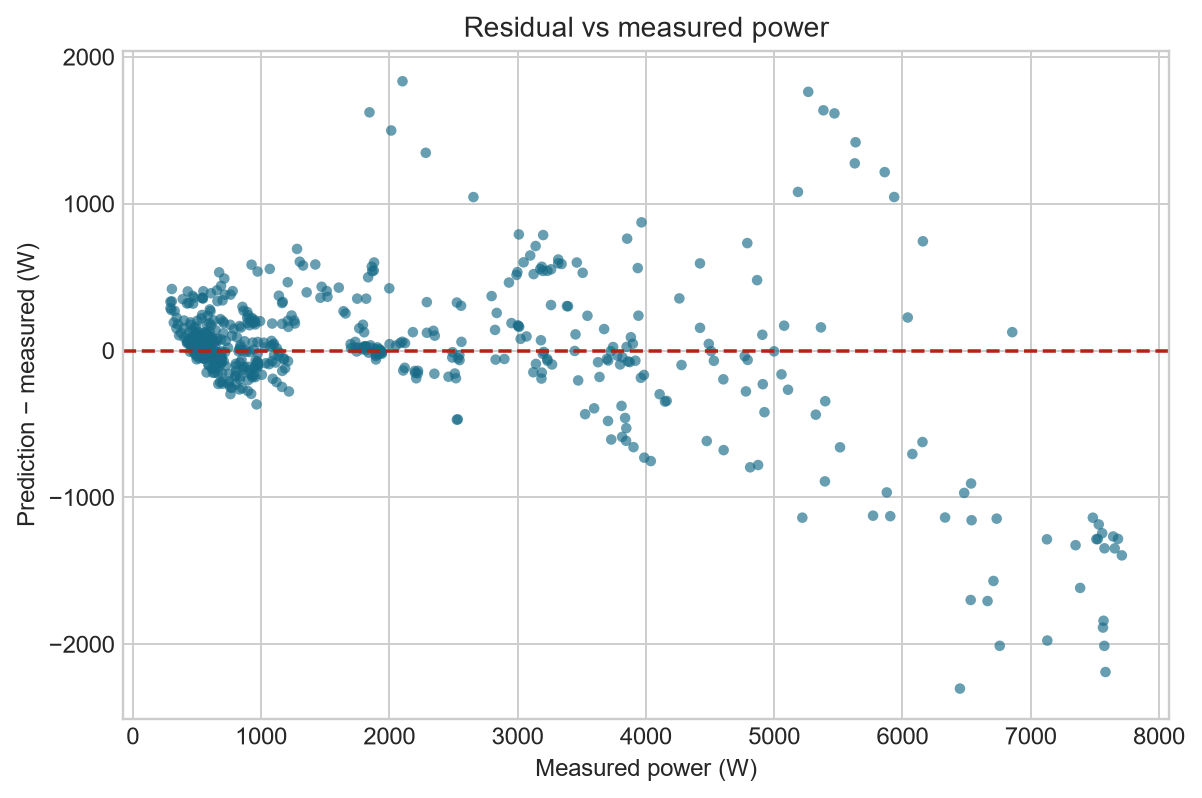

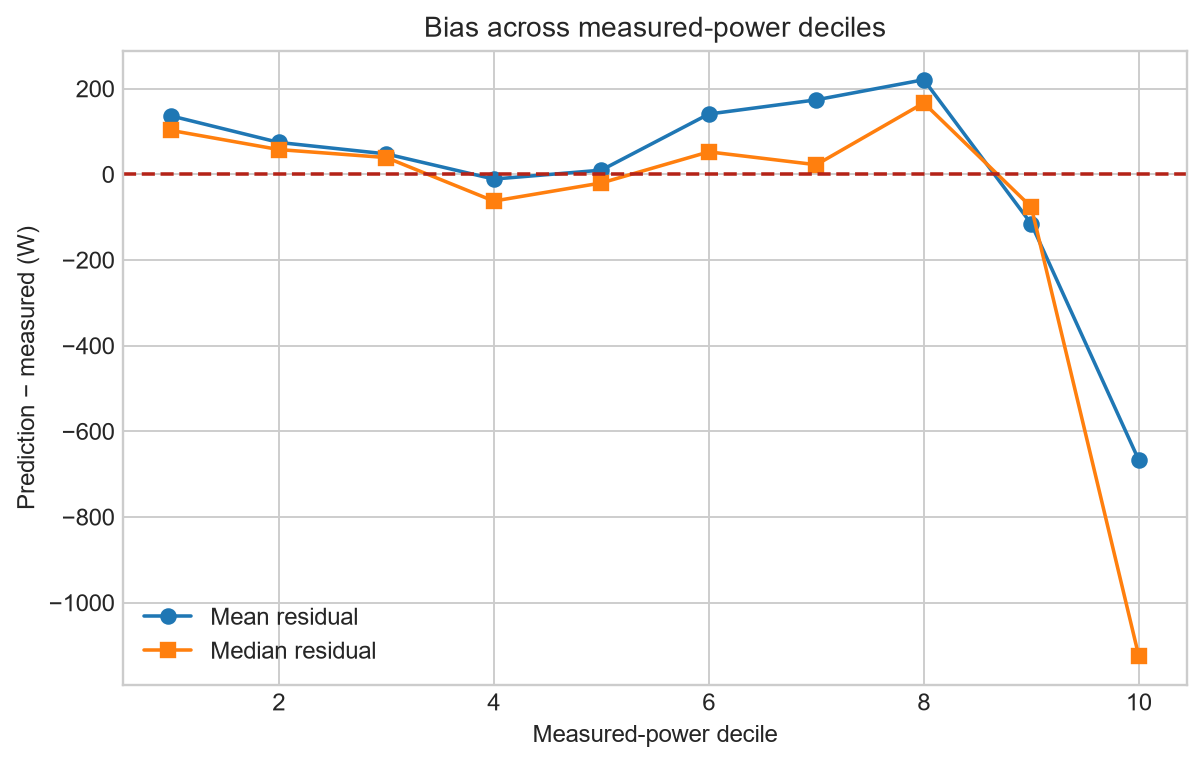

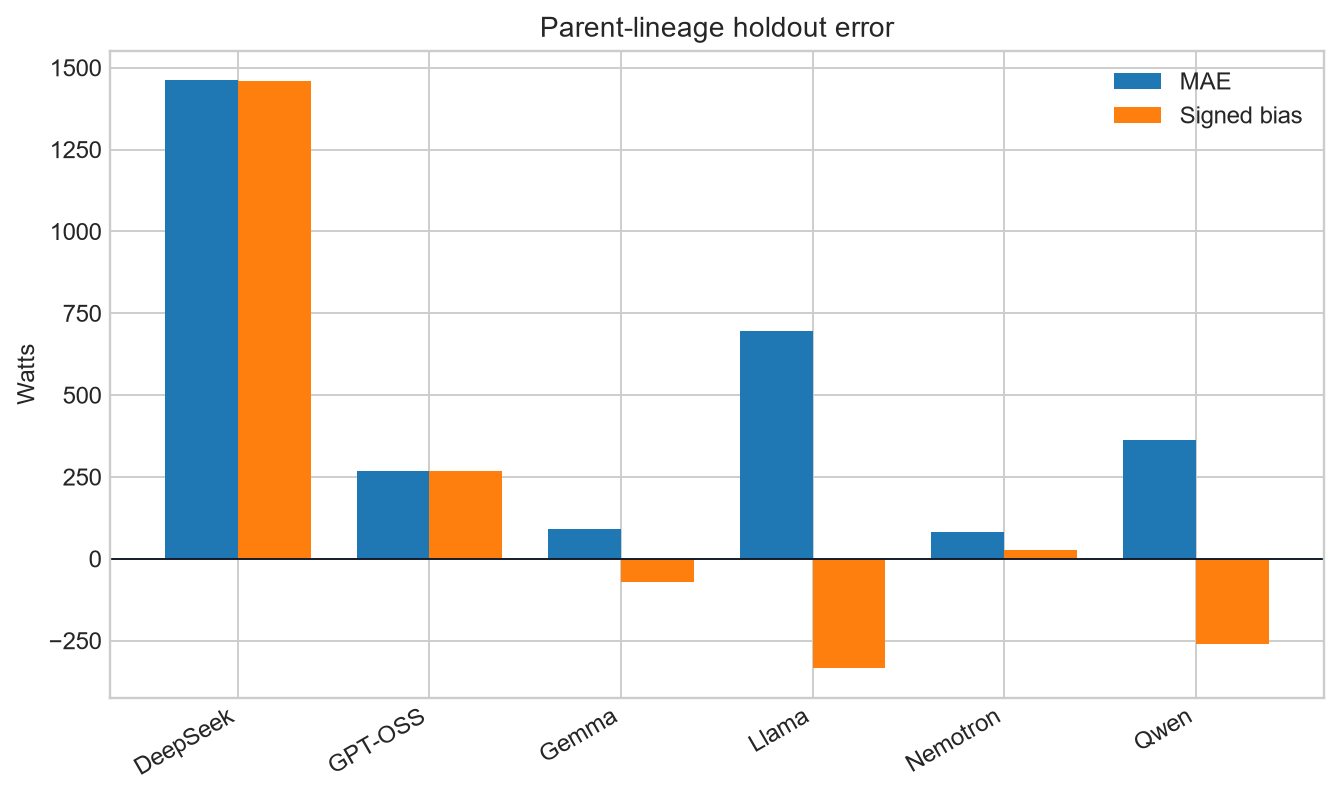

In [5]:
display(lineage[["diag_parent_lineage", "n_runs", "n_models", "mae", "rmse", "r2", "signed_bias"]].round(3))
display(within_task[["x_protocol_task", "diag_parent_lineage", "task_lineage_confounded", "n_runs", "n_models", "mae", "signed_bias"]].round(3))
display(architecture[["diag_architecture_class", "n_runs", "n_models", "mae", "rmse", "r2", "signed_bias"]].round(3))
display(
    slices.loc[slices["slice_type"].isin(["gpu_model", "gpu_count", "top_25_percent", "top_10_percent", "calibration"])]
    .round(3)
)
for name in ("residual_vs_measured_power.png", "top_power_quantile_bias.png", "lineage_holdout_mae_bias.png"):
    display(Image(filename=str(FIGURES / name), width=950))


## Takeaways

1. Move the main GPU-power study from the 305-run physics cohort to all 565 stable runs; retain smaller cohorts only for mechanism diagnostics.
2. Keep RandomForest + P2 + L1 as the Phase 4 candidate baseline. Its one-shot confirmatory MAE is 295.3 W, but per-lineage outcomes vary sharply.
3. Aggregate rated power is useful for some learners and explains most of the static-subset gain; the final RandomForest also benefits from the broader P2 representation.
4. Reintroducing Llama and other lineages improves coverage, not lineage robustness. DeepSeek, Llama, Qwen, 8-GPU, and top-power cases remain the priority.
5. Do not yet treat this as a general cross-accelerator or node-power model. First collect difficult lineage/high-power combinations and define extrapolation acceptance gates.
